In [7]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
# import lib_plot

from lib_fitting import lin_fit
from lib_equations import trapezoidal, Simpson, Gauss_Leg


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **2-Points Gauss Quadrature**

In [8]:
# Params
a = -1
b = 1
dx_ = 1e-6

func = np.exp

res = Gauss_Leg(func, a, b, dx_)

# Results
print(f'a = {a}')
print(f'b = {b}\n')
true = func(b) - func(a)

print('true =', true)
print('I{a, b} =', res)
print('\ndiff =', abs(true - res))


a = -1
b = 1

true = 2.3504023872876028
I{a, b} = 2.350402387287603

diff = 4.440892098500626e-16


# **Comparison between the different methods**

In [9]:
func = lambda x: 4 / (1 + x**2)

a, b = (0, 1)
dx_ = 1e-5

res_t = trapezoidal(func, a, b, dx_)
res_s = Simpson(func, a, b, dx_)
res_g = Gauss_Leg(func, a, b, dx_)
true  = np.pi

diff_t = abs(true - res_t)
diff_s = abs(true - res_s )
diff_g = abs(true - res_g )

# Results
print(f'a = {a}')
print(f'b = {b}')
print('True =', true)

print('\n\nTrapezoidal\'s Rule:')
print('\nI_t =', res_t)
print('diff =',diff_t)

print('\n\nSimpson\'s Rule')
print('\nI_s =', res_s)
print('diff =',diff_s)

print('\n\n2-point Gauss-Legendre quadrature\'s Rule')
print('\nI_g =', res_g)
print('diff =',diff_g)


a = 0
b = 1
True = 3.141592653589793


Trapezoidal's Rule:

I_t = 3.1415726533731254
diff = 2.0000216667703796e-05


Simpson's Rule

I_s = 3.141592653589794
diff = 8.881784197001252e-16


2-point Gauss-Legendre quadrature's Rule

I_g = 3.1415926535897936
diff = 4.440892098500626e-16


## **Analitic evaluation of $N$ value needed to reach $\epsilon=10^{-6}$**

In [10]:
# Params
dx_span = np.logspace(-7, -0.5, 50)
eps = 1e-14
error = [[], [], []]

for dx_ in dx_span:
    for i in range(3):
        gr_spec = [['Trapezoidal', '.', trapezoidal], 
                [ 'Simpson', 'v', Simpson],
                [ 'Gauss-Legendre', '*', Gauss_Leg]]
        
        f_int = gr_spec[i][2]
        err = np.abs(f_int(func, a, b, dx=dx_) - true)
        error[i].append(err)

error = np.array(error)
N_span = ((b-a) / dx_span)


dof = 47

a = 1.00e+00 +/- 7.615e-02
b = -5.70e-02 +/- 3.148e-01

Chi2 = 4.87
p-val = 1.00


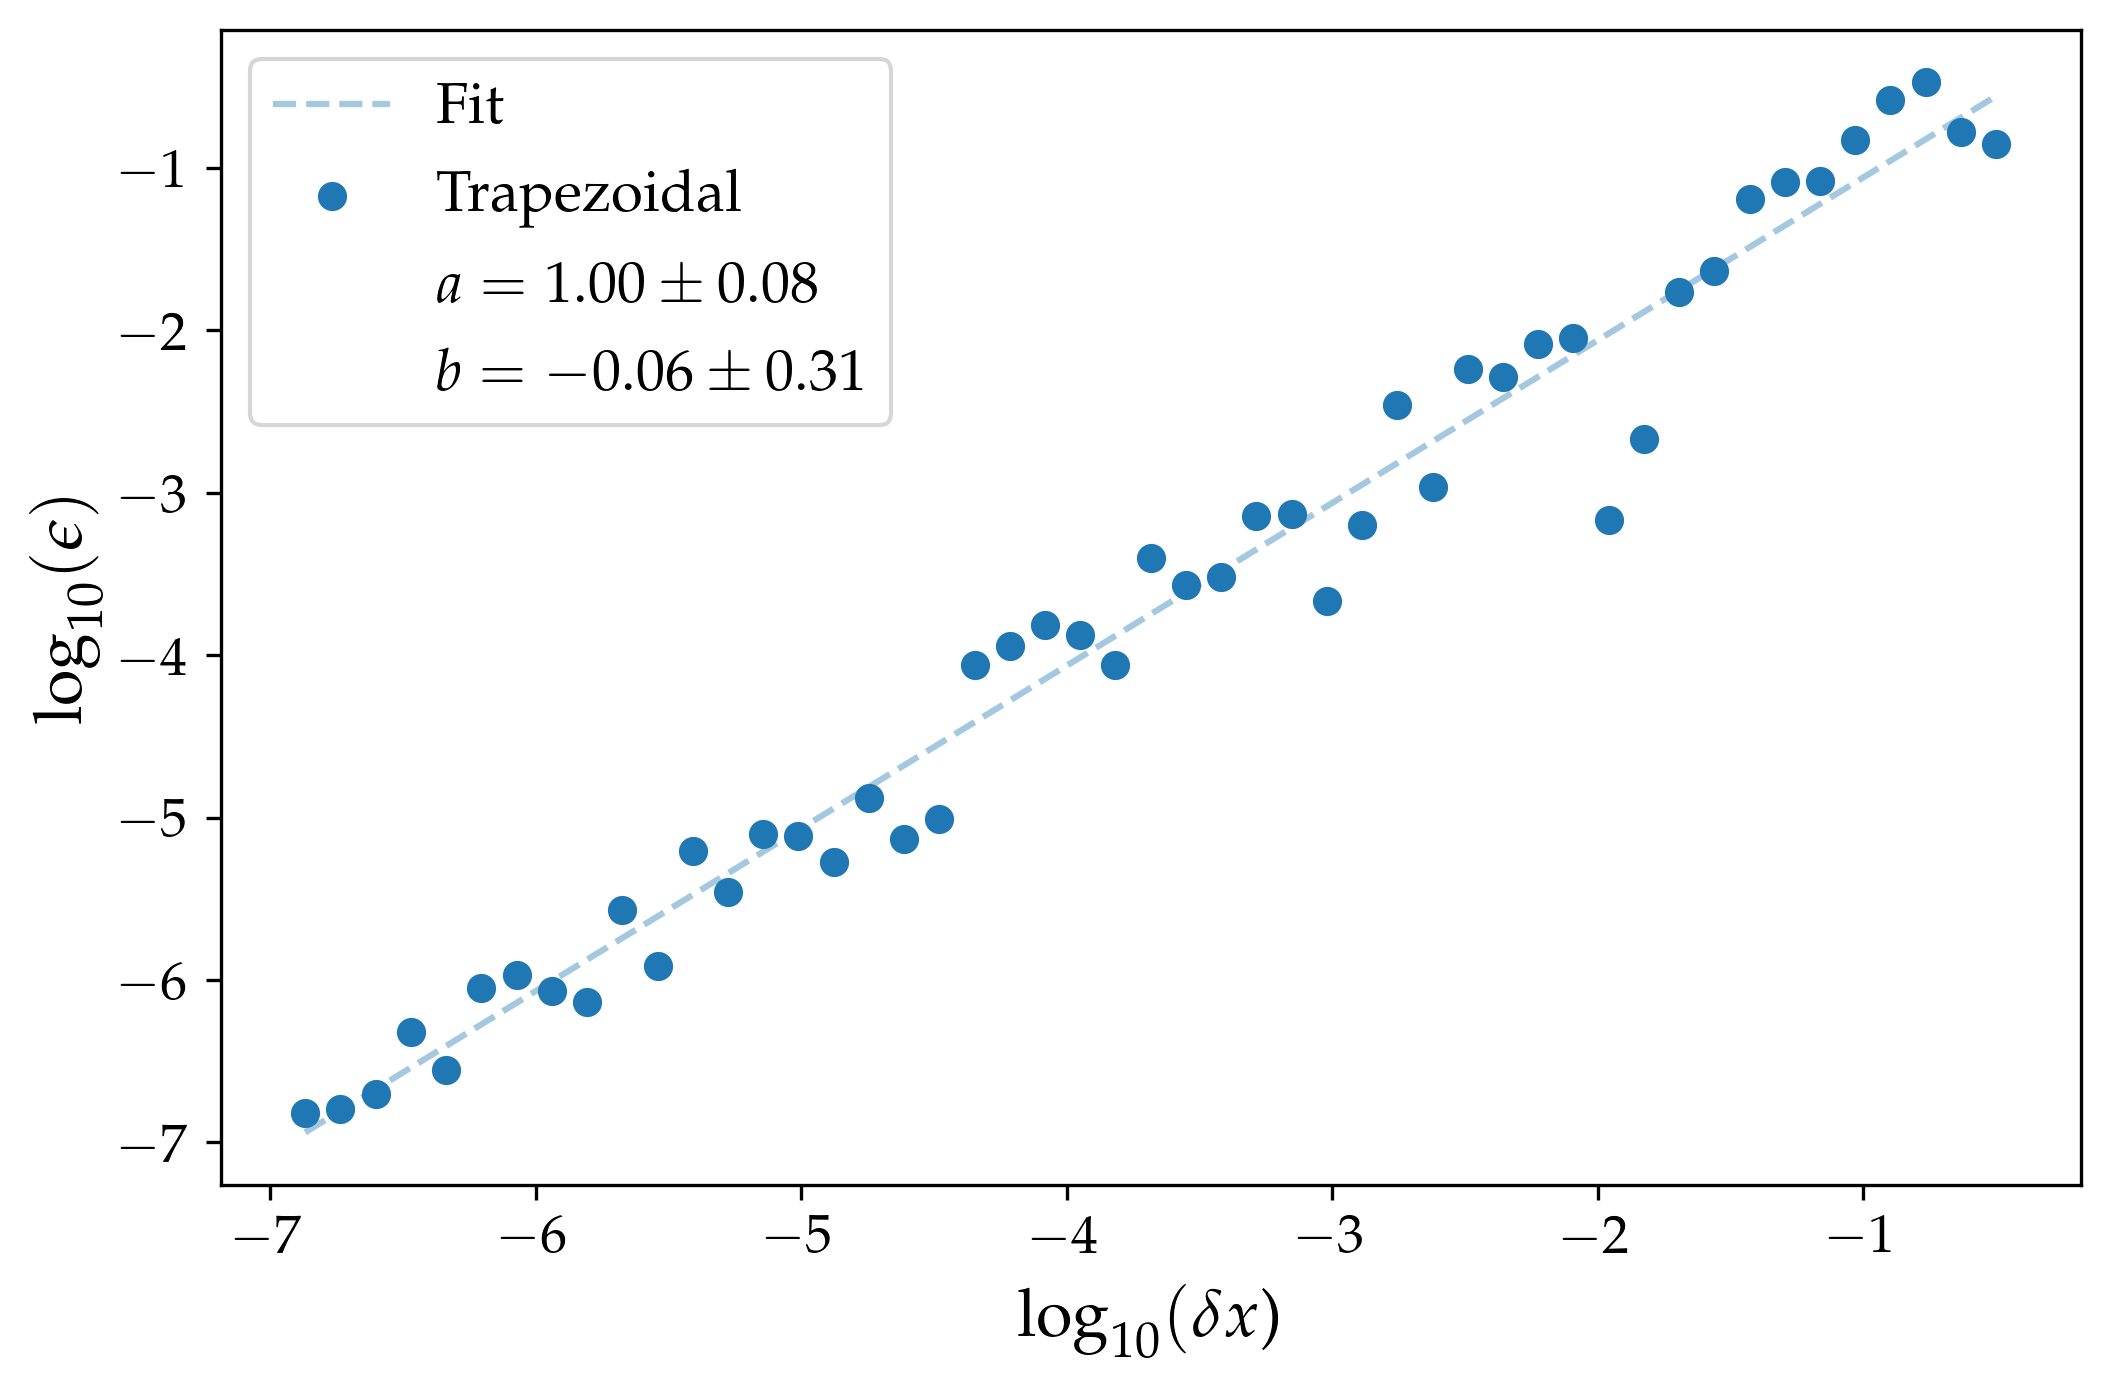

In [11]:
i = 0 
cut = 1
dx, eps_dx = (dx_span[cut:], error[i][cut:])

res_t = lin_fit(np.log10(dx), np.log10(eps_dx), np.eye(len(dx)), 1,
        mar='o', col='C0', name_points='Trapezoidal',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), ErrTrue=False,)

dof = 8

a = 6.07e+00 +/- 8.300e-01
b = -1.27e+00 +/- 9.638e-01

Chi2 = 0.40
p-val = 1.00


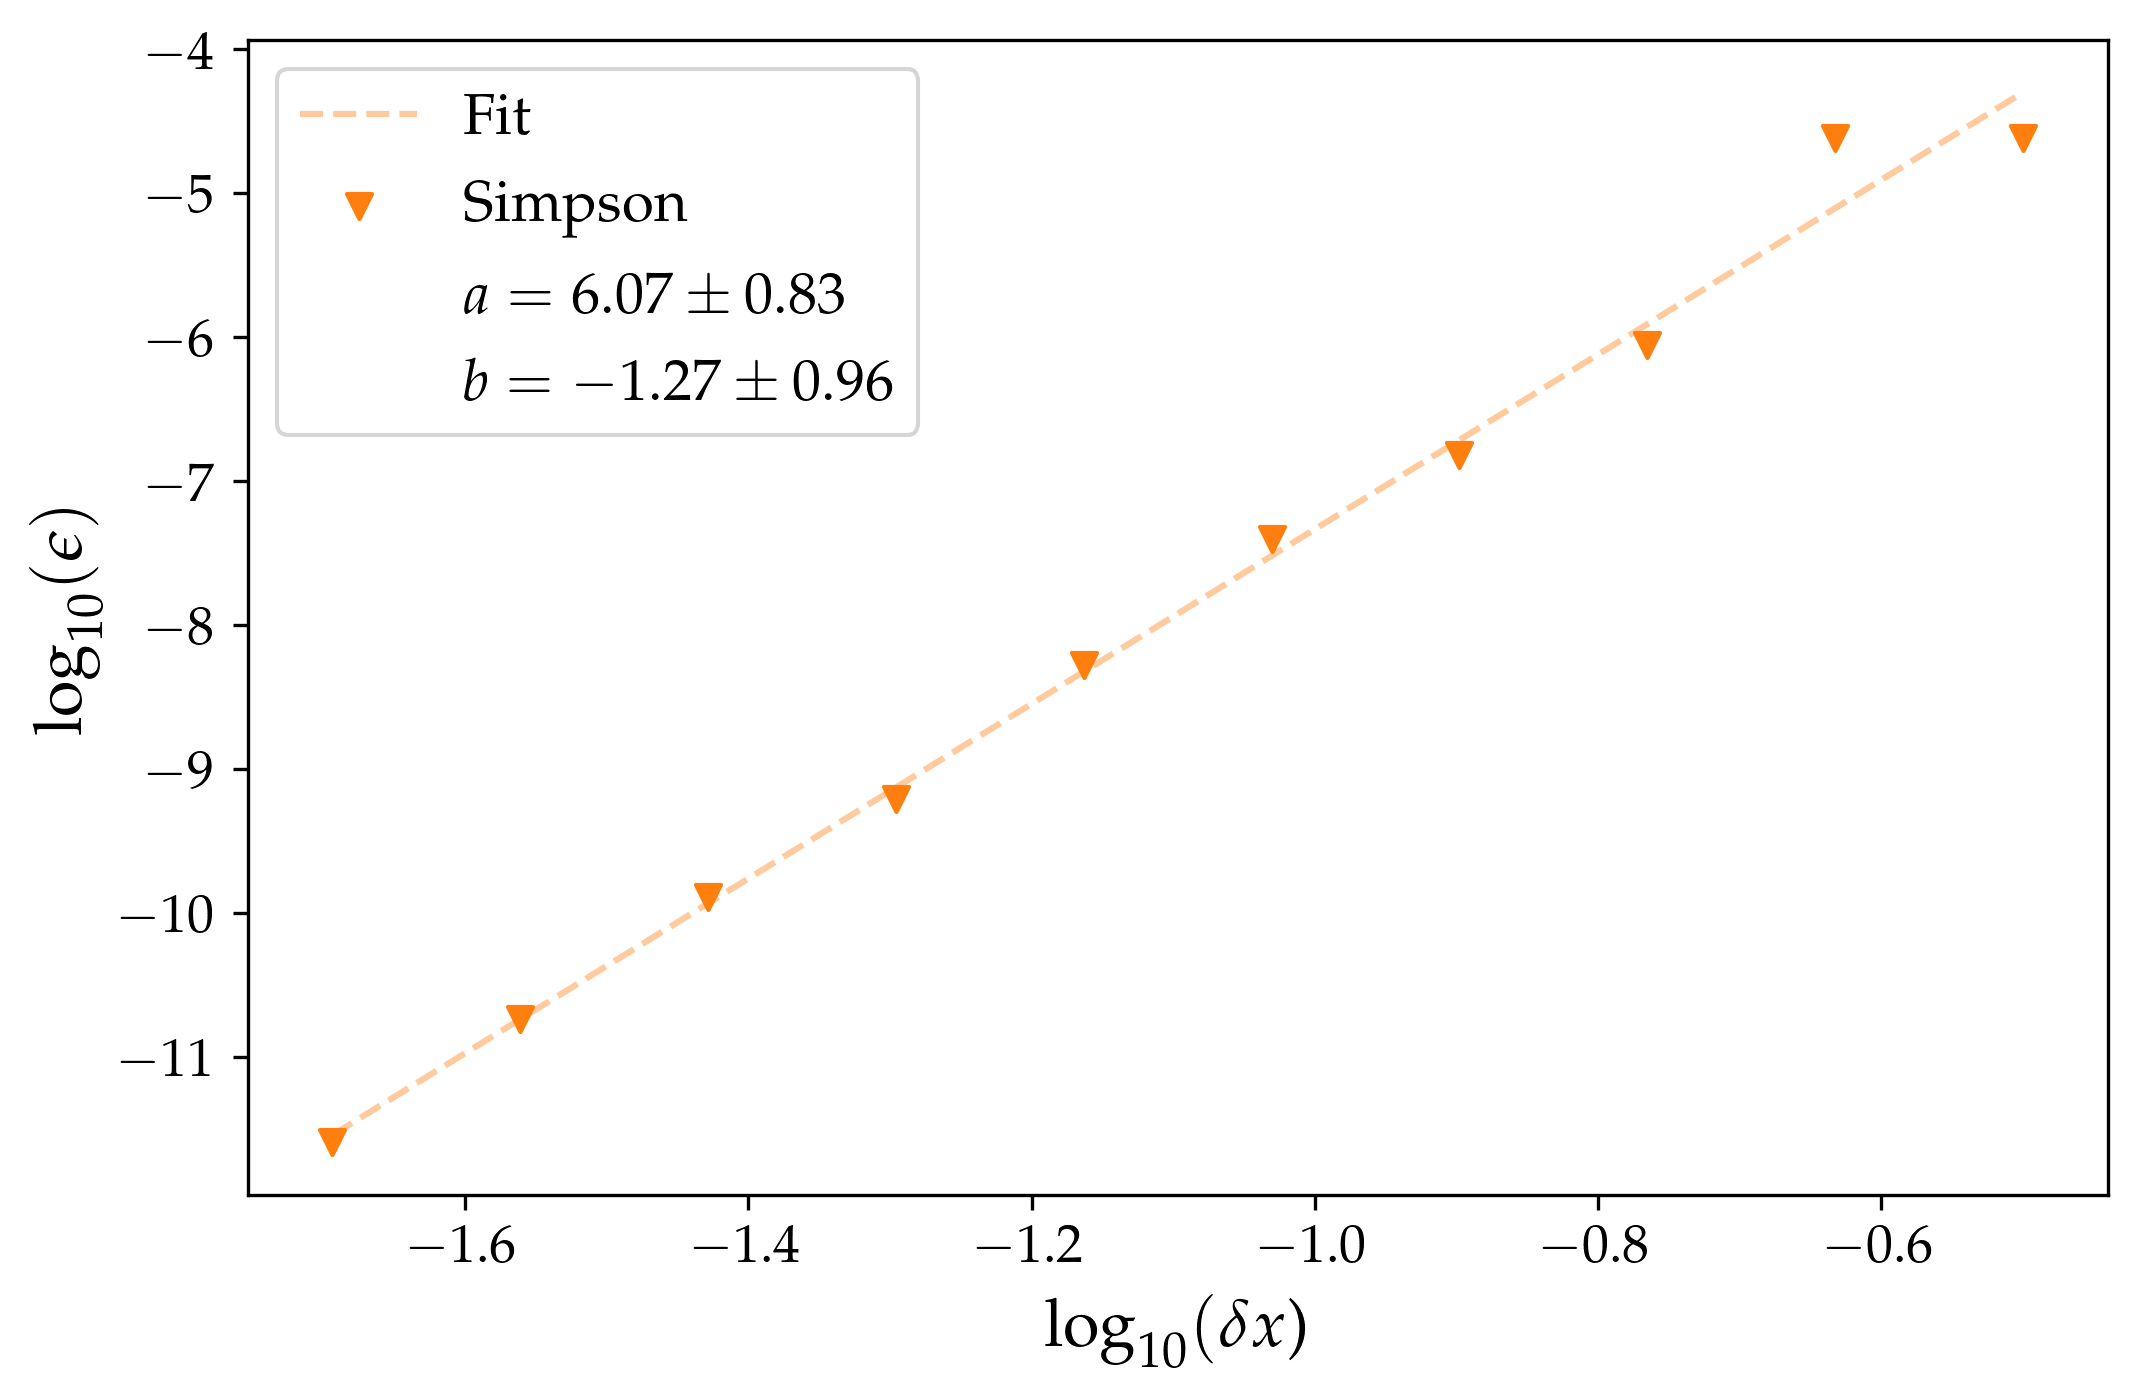

In [12]:
i = 1
cut = 40
dx, eps_dx = (dx_span[cut:], error[i][cut:])

res_s = lin_fit(np.log10(dx), np.log10(eps_dx), np.eye(len(dx)), 1,
        mar='v', col='C1', name_points='Simpson',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), ErrTrue=False,)

dof = 8

a = 6.21e+00 +/- 8.300e-01
b = -2.97e+00 +/- 9.638e-01

Chi2 = 0.07
p-val = 1.00


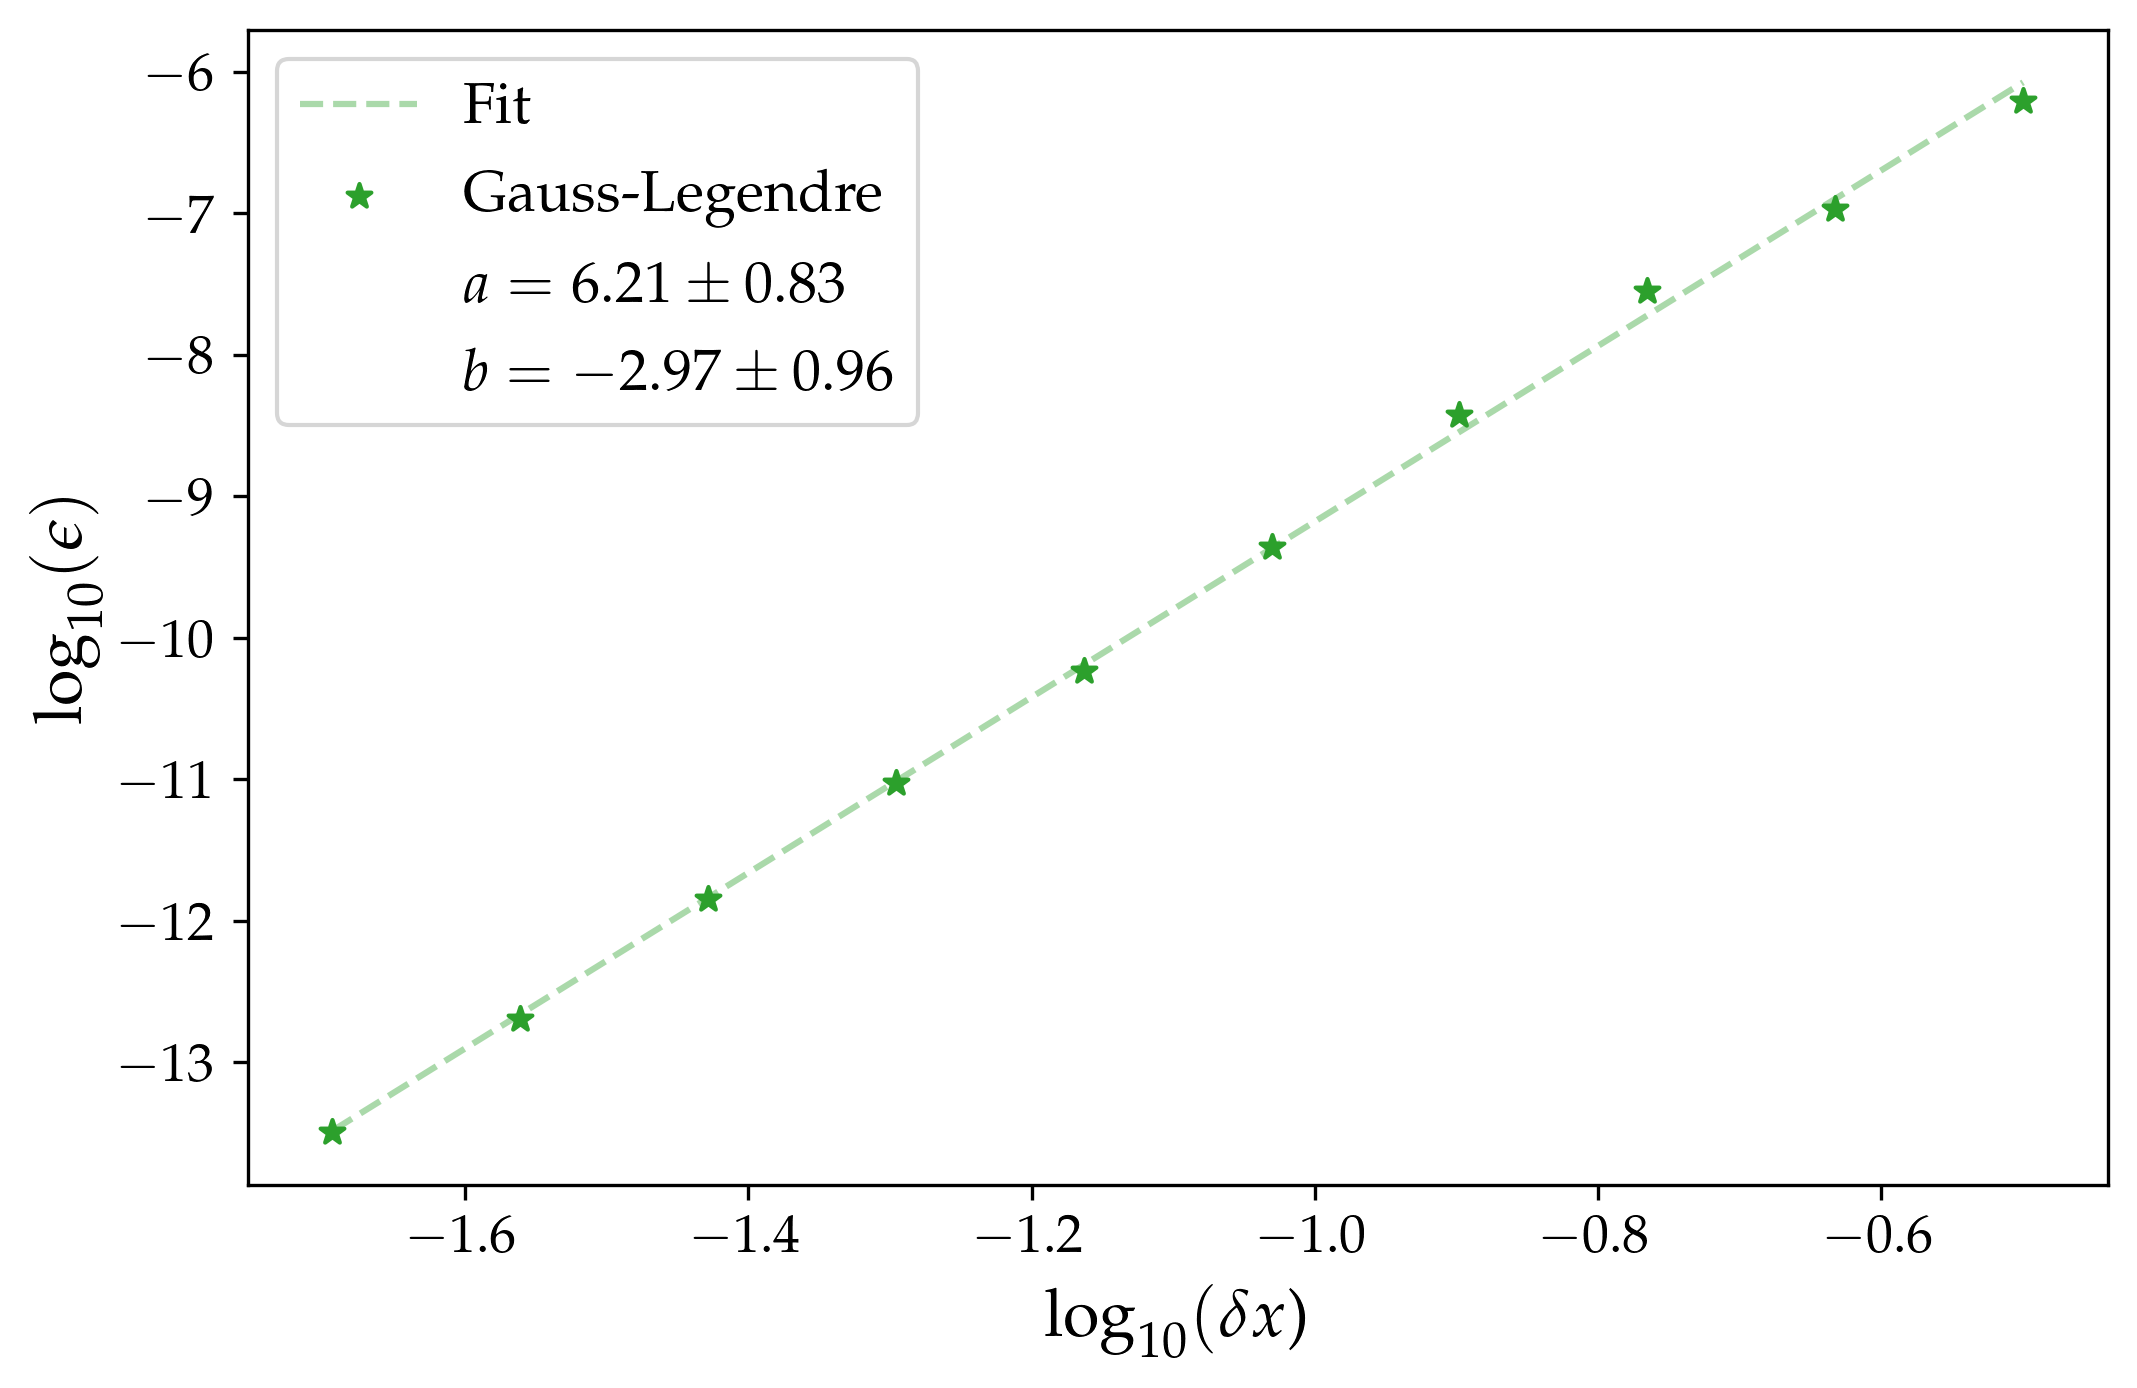

In [13]:
i = 2
cut = 40
dx, eps_dx = (dx_span[cut:], error[i][cut:])

res_g = lin_fit(np.log10(dx), np.log10(eps_dx), np.eye(len(dx)), 1,
        mar='*', col='C2', name_points='Gauss-Legendre',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), ErrTrue=False,)

In [14]:
p_t = res_t[0][0]
print('p_t =', p_t)

p_s = res_s[0][0]
print('p_s =', p_s)

p_g = res_g[0][0]
print('p_g =', p_g)
print()

p_mean = np.mean([p_s, p_g])

eval_N = lambda eps, p: int((eps)**(-1/p))
epsilon = 1e-6
N2 = eval_N(epsilon, p_t)
N4 = eval_N(epsilon, p_mean)

print('eps =', epsilon)
print(f'\nif p = {p_t:.1f}:')
print('     N =', N2)
print(f'\nif p = {p_mean:.1f}:')
print('     N =', N4)

p_t = 1.0019194425836455
p_s = 6.068241705343291
p_g = 6.205684685524044

eps = 1e-06

if p = 1.0:
     N = 973879

if p = 6.1:
     N = 9


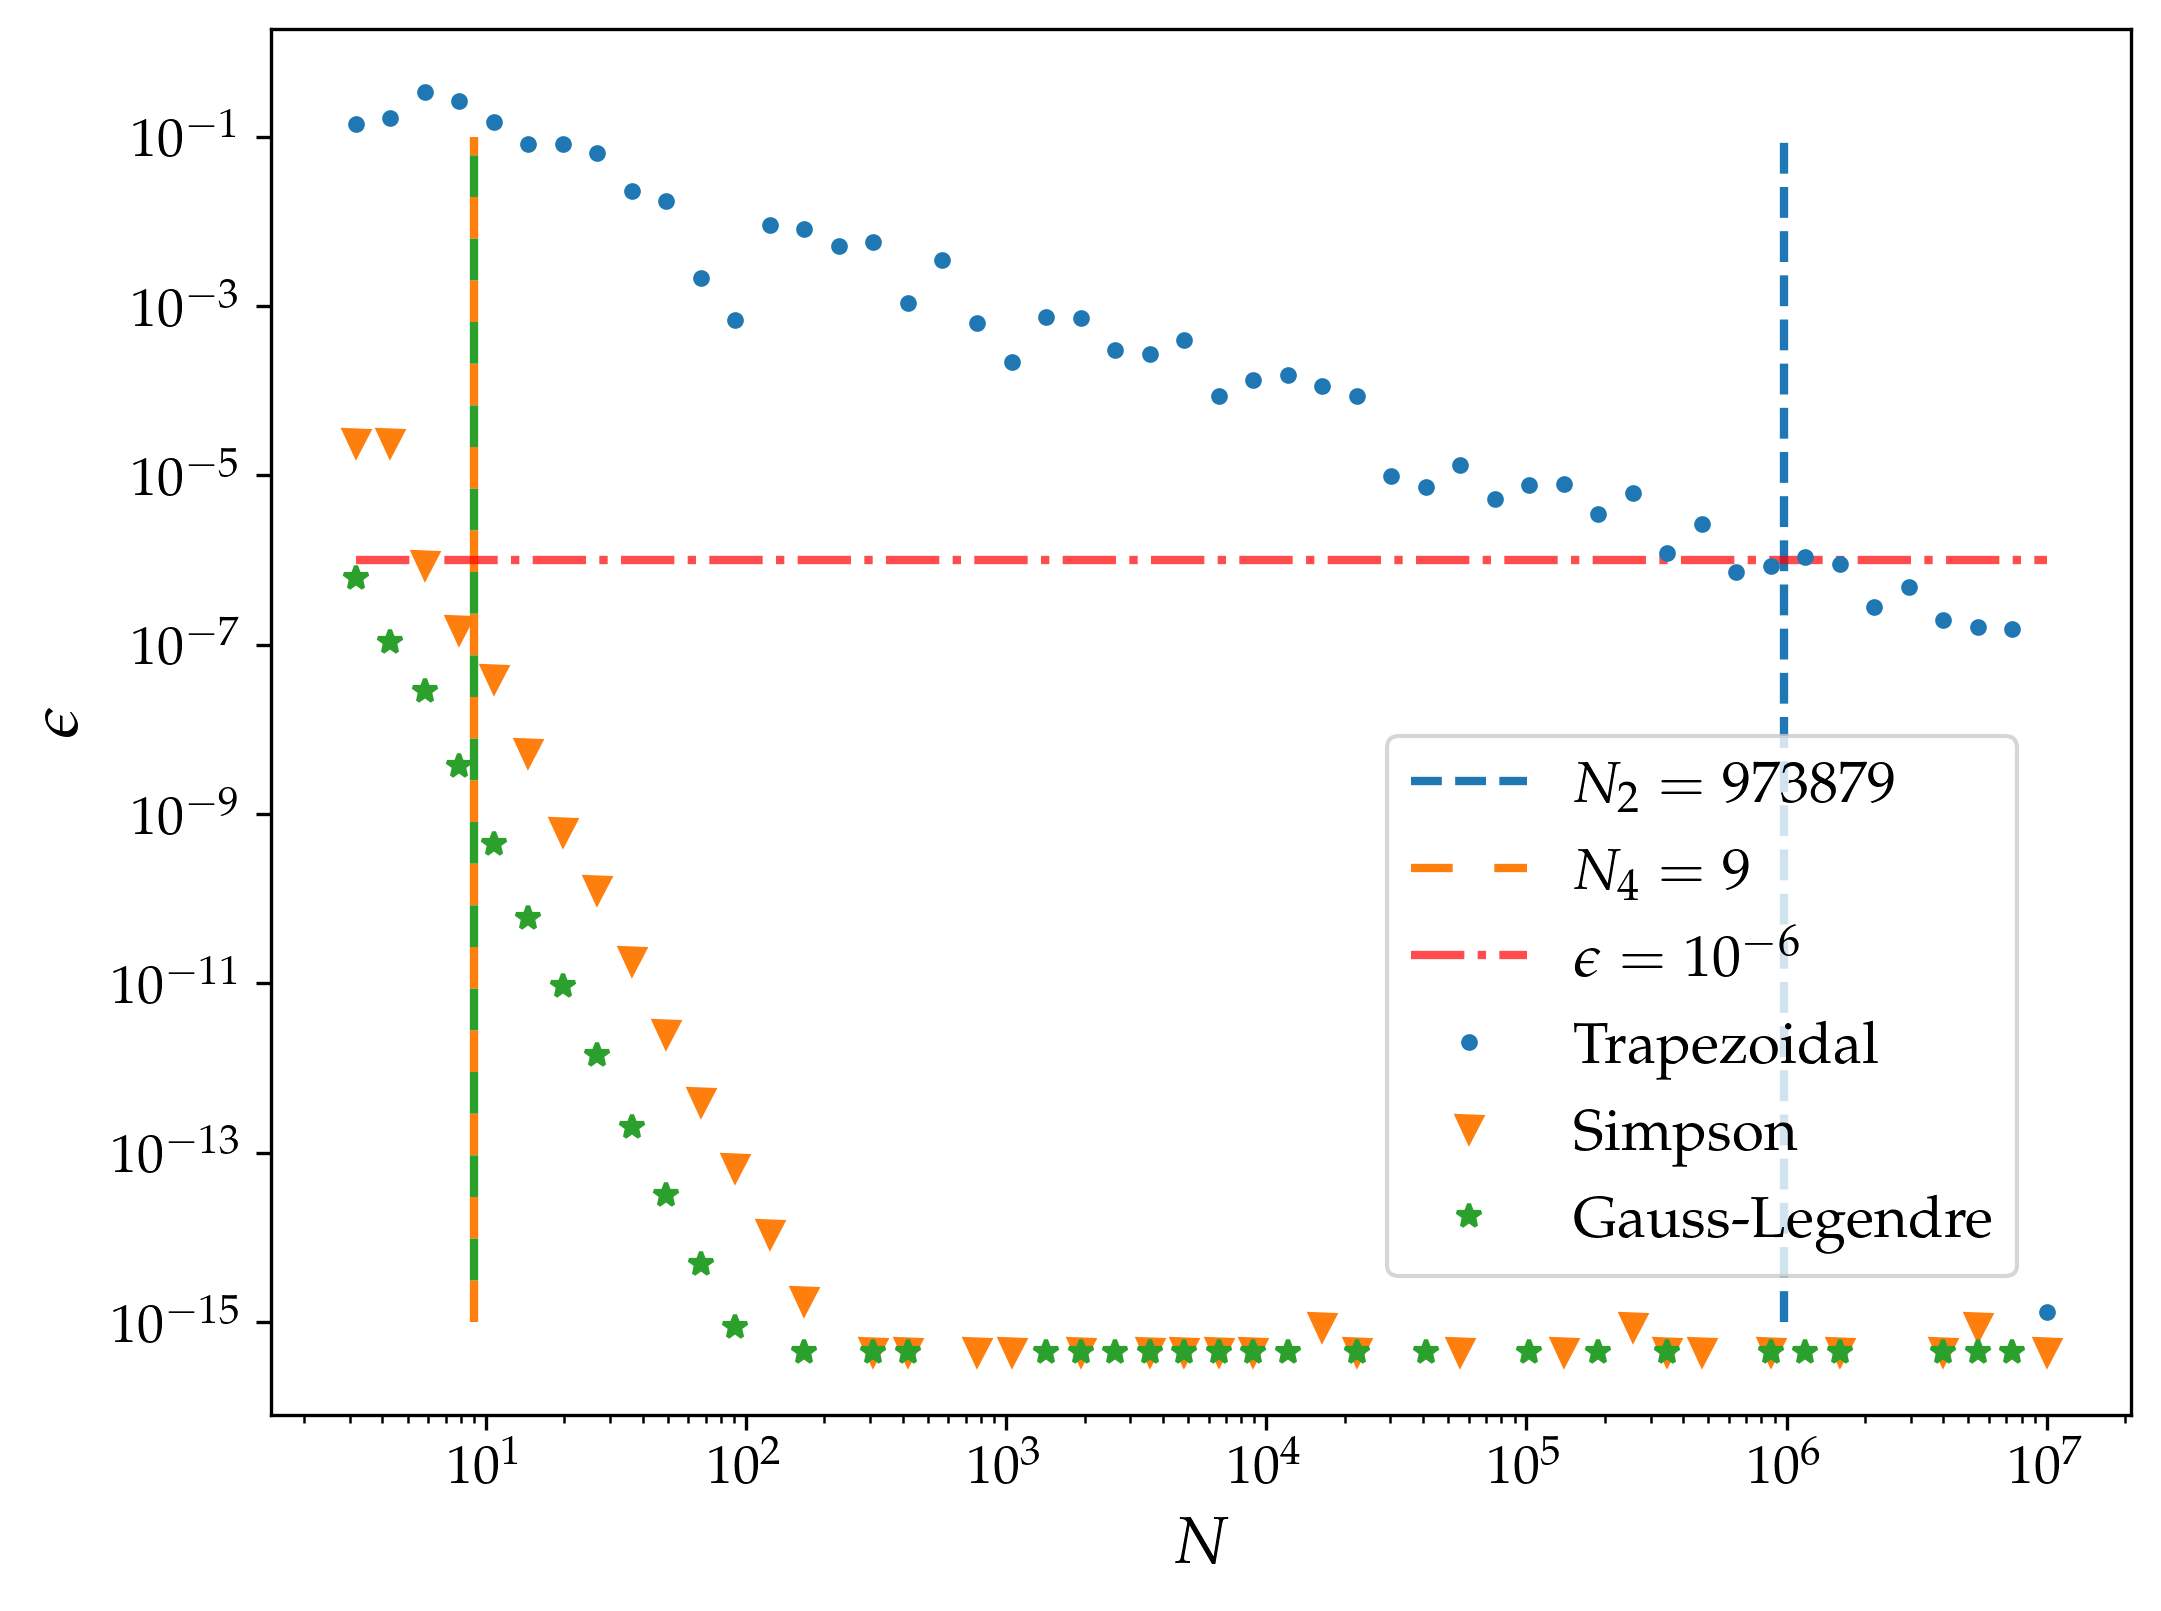

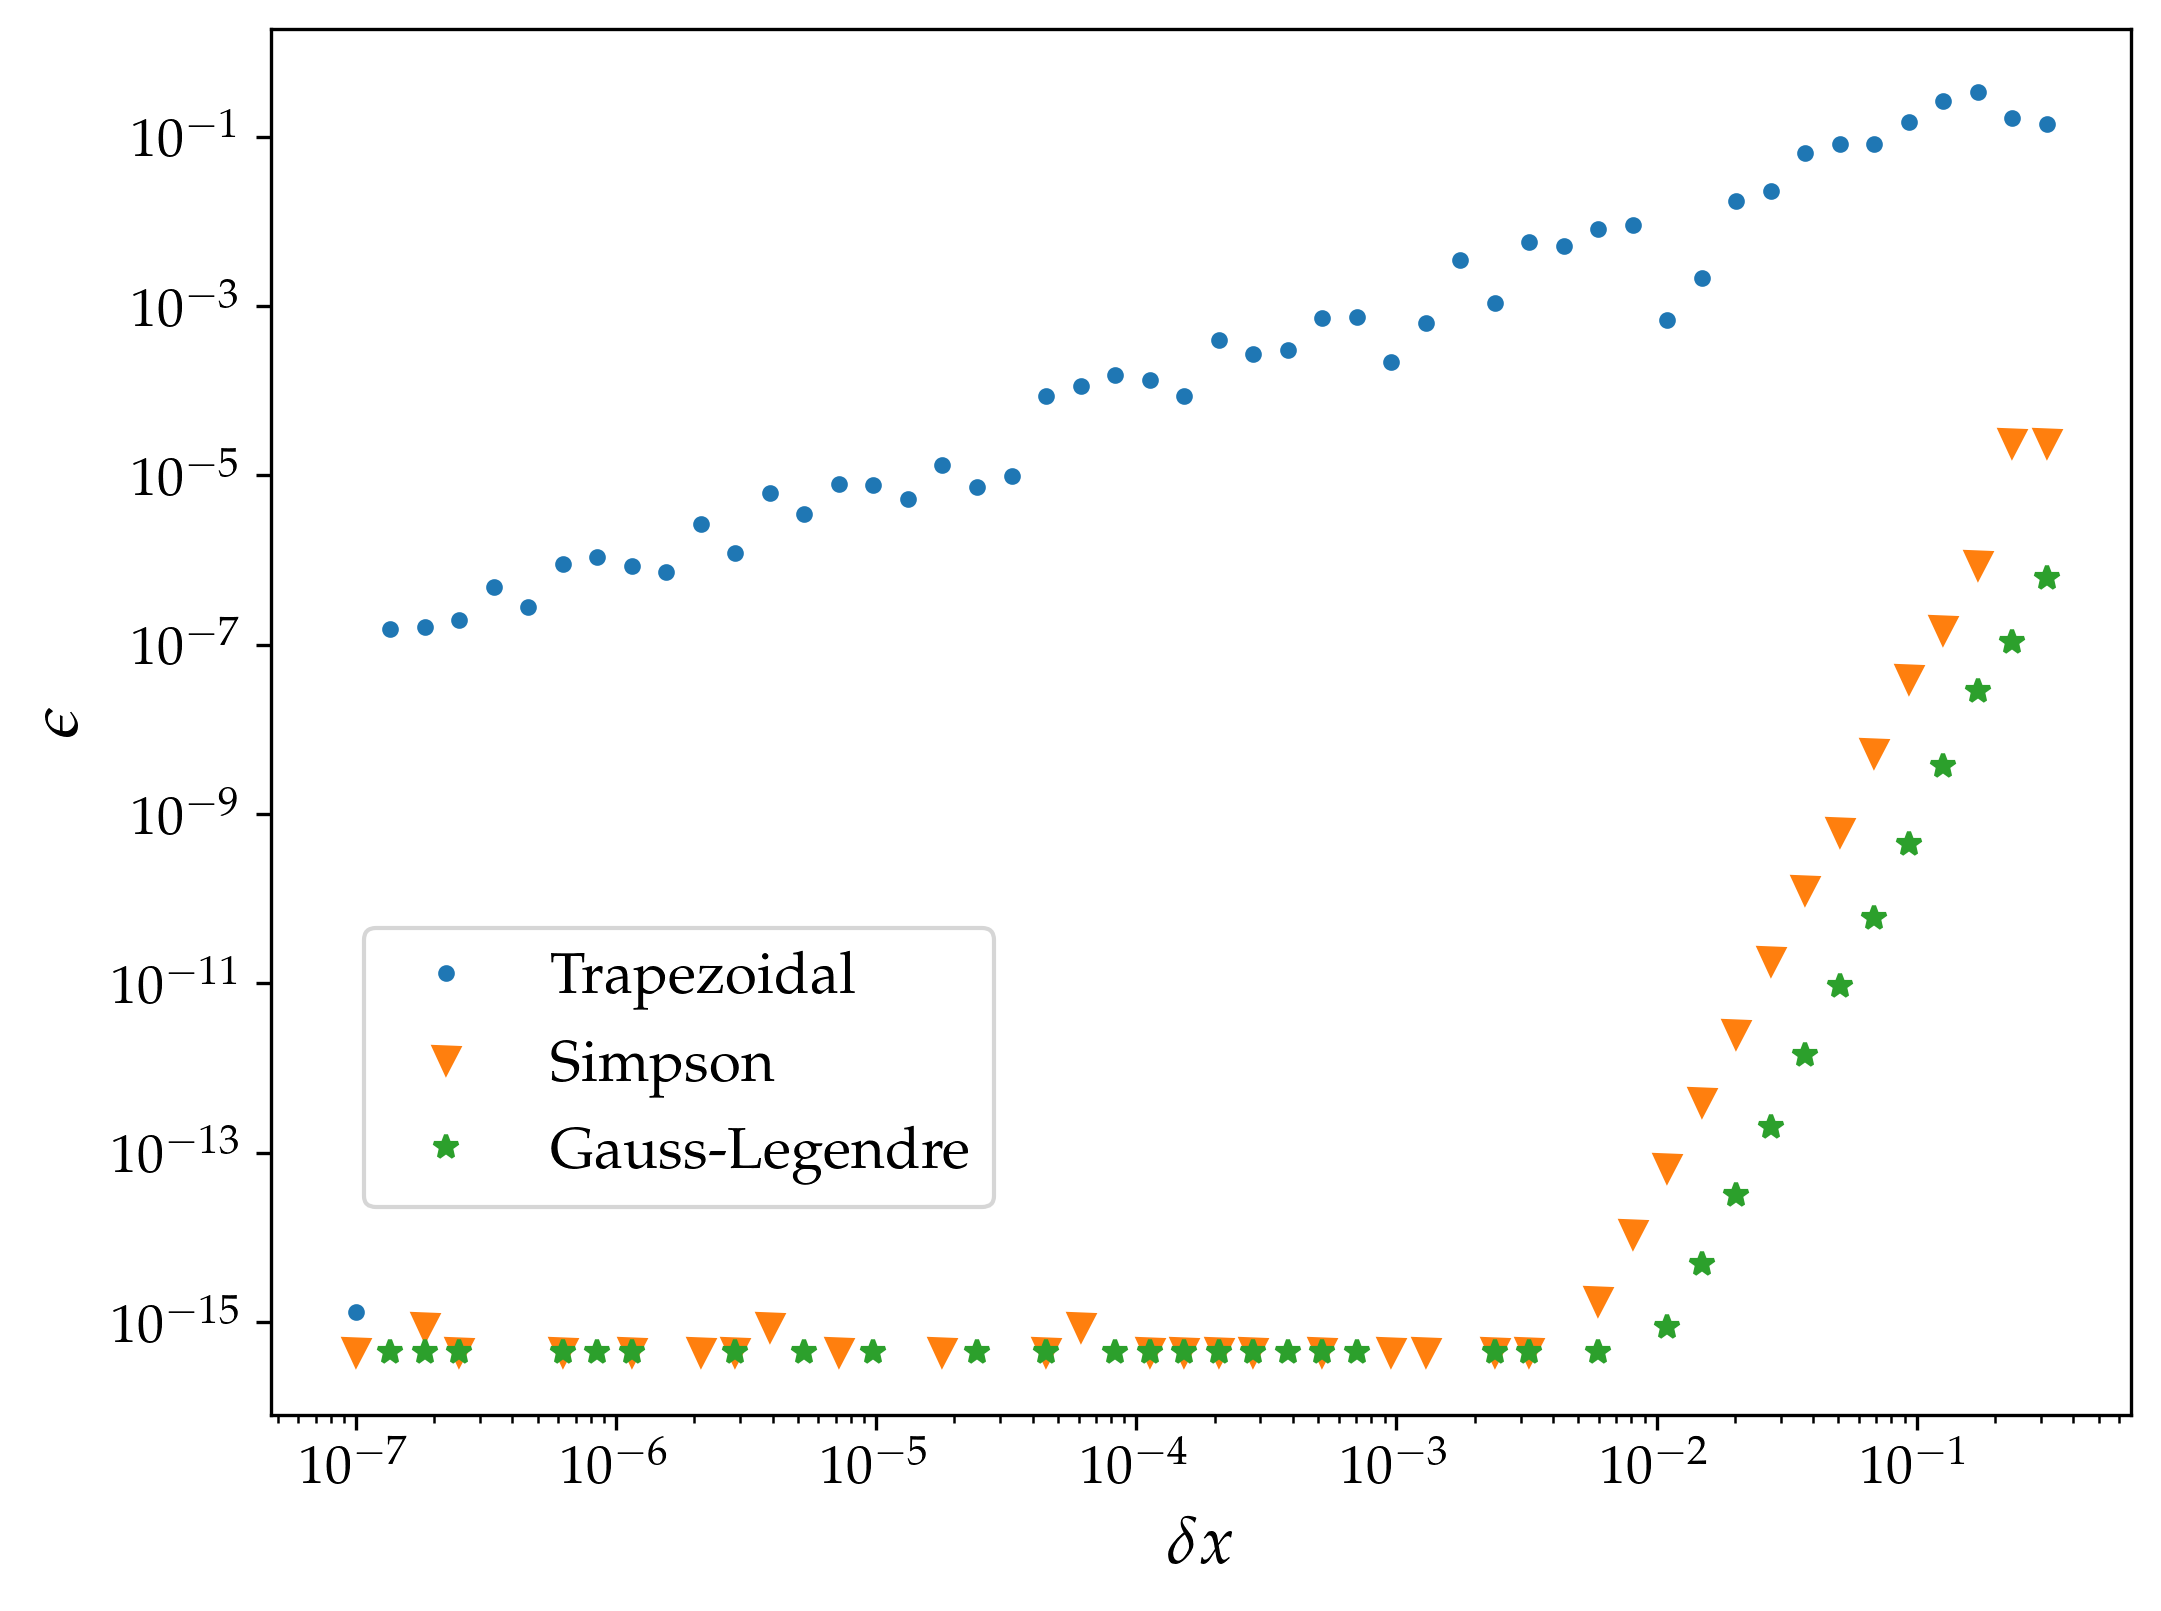

In [15]:

# N_2
plt.vlines(N2, 1e-15, 1e-1, color='C0', ls='--', lw=2,
            label=rf'$N_2 = {N2}$')

# N_4
len_dash = 5
ax = plt.gca()
vl1 = plt.vlines(N4, 1e-15, 1e-1, color='C1', lw=2, 
                 linestyle=(0, (len_dash, len_dash)),
                 label=rf'$N_4 = {N4}$')
vl2 = plt.vlines(N4, 1e-15, 1e-1, color='C2', lw=2, 
                 linestyle=(len_dash, (len_dash, len_dash)))

# epsilon
plt.hlines(epsilon, np.min(N_span), np.max(N_span), color='red', ls='-.',
            alpha=0.7, lw=2, label=r'$\epsilon=10^{-6}$')

for i in range(3):
    plt.loglog(N_span, error[i], ls='', marker=gr_spec[i][1], label=gr_spec[i][0])
    # plt.loglog(dx_span, error[i], ls='', marker=gr_spec[i][1], label=gr_spec[i][0])

plt.xlabel(r'$N$')
plt.ylabel(r'$\epsilon$')
plt.legend(loc=(0.6, 0.1))
plt.show()

for i in range(3):
    plt.loglog(dx_span, error[i], ls='', marker=gr_spec[i][1], label=gr_spec[i][0])

plt.xlabel(r'$\delta x$')
plt.ylabel(r'$\epsilon$')
plt.legend(loc=(0.05, 0.15))
plt.show()
